# J-lens on block outputs (residual deltas) — GPT-2 XL

Block l writes `Δ_l = h_l − h_{l−1}` into the residual stream (`h_{−1}` = token + position
embedding). The Jacobian is a differential, so reading the *increment* of each block,
`J_l Δ_l`, is a natural alternative to reading the whole stream, `J_l h_l`.

**Answer (this run).** With the usual min-over-all-layers pass@k, deltas surface more
intermediates, but controls rise too: hits on deltas are sparse and scattered across layers,
and the minimum over 47 layers collects them (§3–4). With the layer chosen on held-out items
(§5), deltas are no better than the stream overall — clearly better only on poetry (rhymes are
written by blocks 41–45 and invisible in the stream), much worse on typo, and no better on
order-ops (the answer accumulates in the stream). J transport adds nothing over plain direct logit attribution
on deltas.

## Method

**Jacobian.** `Δ_l` enters the stream where `J_l = ∂h_final / ∂h_l` is taken, so its
first-order effect on the final stream is `J_l Δ_l`; the snapshot lens is used, no refit.

**Readouts.** `full` = `lm_head(ln_f(x))`, as in the dataset notebooks. `linear` =
`W_U (γ ⊙ center(x))`: the differential of the final norm. The `1/σ` scale is shared by all
tokens and does not change ranks, and the `ln_f` bias — a fixed vocabulary prior that `full`
adds to every pure delta — is dropped.

**Variants.** {logit, J} × {resid, delta} × {full, linear}; `logit/delta/linear` is classic
direct logit attribution (DLA) of each block. All use the readout cache of
`fit_convergence_ci.ipynb` (`RUN_DIR/eval_cache_v<version>.pt`) and the shared model-output row.
Target IDs and derived ranks are scoring-versioned; old prefix-answer caches are not reused.
Unsupported targets have null scores. Saved outputs are historical; rerun to refresh them.

**Statistics.** Intermediate vs control (words of another item) and their *margin*; paired
item bootstrap within each dataset. §5 removes the min-over-layers advantage by choosing the
layer on one half of the items and scoring the other half.

## Setup

In [1]:
import os
import sys
from pathlib import Path

REPO_URL = "https://github.com/ai360-project-school-j-lens/jacobian-lens-gpt2.git"
REPO_DIR = os.path.abspath("jacobian-lens-gpt2")

# Opened from a clone (notebooks/<lens>/): use the repository root above the notebook.
local_repo = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "jlens" / "readout_cache.py").is_file()), None)
if local_repo is not None:
    REPO_DIR = str(local_repo)
elif os.path.isdir(REPO_DIR):
    !git -C {REPO_DIR} pull --ff-only
else:
    !git clone {REPO_URL} {REPO_DIR}
sys.path.append(REPO_DIR)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import transformers
from IPython.display import display
from tqdm.auto import tqdm

import jlens
from gpt2 import GPT2LensModel
from jlens.evaluation import DATASETS, load_eval, readout_position
from jlens.readout_cache import (
    READOUT_CACHE_VERSION,
    ReadoutCache,
    WordRanker,
    item_scores,
)

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 240)

In [3]:
MODEL_ID = "openai-community/gpt2-xl"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
RUN_DIR = Path(os.environ.get("JLENS_RUN_DIR", Path(REPO_DIR) / "runs" / "gpt2-xl-convergence"))
OUT_DIR = RUN_DIR / "deltas"
K = 10
ITEM_BOOT = 2000
CV_SPLITS, CV_BOOT, CV_BOOT_SPLITS, CV_WIDTHS = 200, 1000, 20, (1, 5)
OUT_DIR.mkdir(parents=True, exist_ok=True)
rng = np.random.default_rng(2)

cache = ReadoutCache.load(RUN_DIR / f"eval_cache_v{READOUT_CACHE_VERSION}.pt")  # built by fit_convergence_ci.ipynb
H, words = cache.H, cache.words
N_INNER = H.shape[1] - 1
lens = jlens.JacobianLens.load(str(RUN_DIR / "snapshot_lens_134.pt"))
ranker = WordRanker(words, DEVICE)

hf_head = transformers.GPT2LMHeadModel.from_pretrained(MODEL_ID)
unembed = torch.nn.Sequential(hf_head.transformer.ln_f, hf_head.lm_head).to(DEVICE).eval().requires_grad_(False)
gamma, W_U = unembed[0].weight, unembed[1].weight
del hf_head


def linear_readout(x: torch.Tensor) -> torch.Tensor:
    """Differential of ln_f + lm_head up to the shared 1/sigma: W_U (gamma * center(x))."""
    return ((x - x.mean(-1, keepdim=True)) * gamma) @ W_U.T

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

## 1. Embeddings and deltas

`Δ_0` needs the input of block 0. One forward per item records it; the same pass checks that
the block-0 outputs equal the cached `h_0`, so items line up with the cache.

In [4]:
@torch.no_grad()
def block0_io(model):
    captured = {}

    def pre_hook(module, args, kwargs):
        captured["x"] = args[0] if args else kwargs["hidden_states"]

    def hook(module, args, output):
        captured["h0"] = output if torch.is_tensor(output) else output[0]

    handles = [model.layers[0].register_forward_pre_hook(pre_hook, with_kwargs=True),
               model.layers[0].register_forward_hook(hook)]
    inputs, outputs = [], []
    try:
        for dataset in DATASETS:
            for item in load_eval(REPO_DIR, dataset):
                input_ids = model.encode(item["prompt"].rstrip())
                position = readout_position(model.tokenizer, input_ids[0].tolist(), dataset)
                model.forward(input_ids)
                inputs.append(captured["x"][0, position].float().cpu())
                outputs.append(captured["h0"][0, position].float().cpu())
    finally:
        for handle in handles:
            handle.remove()
    return torch.stack(inputs), torch.stack(outputs)


ranks_path = OUT_DIR / f"deltas_ranks_v{READOUT_CACHE_VERSION}.npz"
if ranks_path.exists():
    raw = np.load(ranks_path)
    ranks = {key.replace("__", "/"): raw[key] for key in raw.files}
else:
    model = GPT2LensModel.from_pretrained(MODEL_ID, device=DEVICE)
    E, h0 = block0_io(model)
    torch.testing.assert_close(h0, H[:, 0], rtol=1e-4, atol=1e-4)
    del model
    residual = H[:, :N_INNER]
    delta = residual - torch.cat([E[:, None], H[:, : N_INNER - 1]], dim=1)
    final = ranker.rank_residuals(unembed, H[None, :, -1])[0]
    ranks = {}
    for lens_name in ("logit", "J"):
        for source_name, source in (("resid", residual), ("delta", delta)):
            x = source.transpose(0, 1)  # [n_inner, n_items, d]
            if lens_name == "J":
                x = torch.stack([x[layer] @ lens.jacobians[layer].float().T for layer in range(N_INNER)])
            for mode, readout in (("full", unembed), ("linear", linear_readout)):
                inner = ranker.rank_residuals(readout, x)
                ranks[f"{lens_name}/{source_name}/{mode}"] = np.concatenate([inner, final[None]]).T
    np.savez_compressed(ranks_path, **{key.replace("/", "__"): value for key, value in ranks.items()})
    rel = (delta.norm(dim=-1) / residual.norm(dim=-1)).mean(0)
    print("mean |delta| / |h| at layers 0, 8, ..., 40:", rel[::8].numpy().round(3))
VARIANTS = list(ranks)
VARIANTS

['logit/resid/full',
 'logit/resid/linear',
 'logit/delta/full',
 'logit/delta/linear',
 'J/resid/full',
 'J/resid/linear',
 'J/delta/full',
 'J/delta/linear']

## 2. Min-over-layers scores

Inner pass@k (best rank over layers 0..46) for every variant, as in the dataset notebooks.

In [5]:
def per_item(variant, dataset, kind, k=K, layers=slice(None, -1)):
    return item_scores(words, ranks[variant], dataset, kind, k=k, layers=layers)


rows = []
for variant in VARIANTS:
    for dataset in DATASETS:
        for kind in ("intermediate", "control"):
            rows.append({"variant": variant, "dataset": dataset, "kind": kind,
                         f"inner pass@{K}": np.nanmean(per_item(variant, dataset, kind)),
                         "mean log10 inner rank": np.nanmean(per_item(variant, dataset, kind, k=None))})
scores = pd.DataFrame(rows)
for kind in ("intermediate", "control"):
    print(f"inner pass@{K}, {kind}")
    display(scores[scores.kind == kind].pivot(index="variant", columns="dataset", values=f"inner pass@{K}")
            [DATASETS].round(3))
print("mean log10 inner rank, intermediate")
display(scores[scores.kind == "intermediate"].pivot(index="variant", columns="dataset",
        values="mean log10 inner rank")[DATASETS].round(3))

inner pass@10, intermediate


dataset,multihop,multilingual,order-ops,poetry,association,typo
variant,,,,,,
J/delta/full,0.409,0.229,0.700,0.163,0.118,0.510
J/delta/linear,0.366,0.229,0.555,0.153,0.108,0.458
J/resid/full,0.280,0.157,0.709,0.000,0.049,0.406
J/resid/linear,0.247,0.159,0.636,0.000,0.029,0.396
logit/delta/full,0.419,0.259,0.845,0.092,0.127,0.458
logit/delta/linear,0.419,0.264,0.727,0.153,0.127,0.438
logit/resid/full,0.280,0.185,0.582,0.010,0.039,0.323
logit/resid/linear,0.269,0.192,0.564,0.020,0.039,0.344


inner pass@10, control


dataset,multihop,multilingual,order-ops,poetry,association,typo
variant,,,,,,
J/delta/full,0.071,0.021,0.53,0.051,0.029,0.042
J/delta/linear,0.071,0.012,0.38,0.041,0.039,0.031
J/resid/full,0.022,0.009,0.47,0.000,0.010,0.000
J/resid/linear,0.022,0.007,0.35,0.000,0.010,0.000
logit/delta/full,0.130,0.037,0.72,0.051,0.049,0.042
logit/delta/linear,0.109,0.036,0.67,0.071,0.049,0.031
logit/resid/full,0.069,0.040,0.49,0.010,0.000,0.021
logit/resid/linear,0.069,0.043,0.47,0.031,0.000,0.010


mean log10 inner rank, intermediate


dataset,multihop,multilingual,order-ops,poetry,association,typo
variant,,,,,,
J/delta/full,1.253,1.775,0.751,1.759,2.002,1.014
J/delta/linear,1.349,1.848,0.919,1.783,2.031,1.118
J/resid/full,1.665,2.307,0.790,2.472,2.534,1.273
J/resid/linear,1.747,2.354,0.882,2.495,2.537,1.327
logit/delta/full,1.220,1.655,0.567,1.789,2.009,1.139
logit/delta/linear,1.291,1.708,0.682,1.767,2.030,1.205
logit/resid/full,1.663,2.141,0.921,2.444,2.677,1.421
logit/resid/linear,1.707,2.147,1.012,2.458,2.676,1.461


### Paired contrasts (95% item-bootstrap CI)

`margin` = intermediate − control per item; a contrast is significant when its CI excludes 0.

In [6]:
CONTRASTS = [
    ("J/delta/linear", "J/resid/full"),
    ("J/delta/full", "J/resid/full"),
    ("J/delta/linear", "logit/delta/linear"),
    ("J/delta/linear", "logit/resid/full"),
    ("logit/delta/linear", "logit/resid/full"),
    ("J/resid/linear", "J/resid/full"),
]


def ci_text(estimate, draws):
    return f"{estimate:+.3f} [{np.percentile(draws, 2.5):+.3f}, {np.percentile(draws, 97.5):+.3f}]"


rows = []
for dataset in DATASETS:
    n_items = len(per_item(VARIANTS[0], dataset, "intermediate"))
    draws = rng.integers(0, n_items, size=(ITEM_BOOT, n_items))
    for a, b in CONTRASTS:
        quantities = {}
        for variant in (a, b):
            inter, control = per_item(variant, dataset, "intermediate"), per_item(variant, dataset, "control")
            quantities[variant] = {"intermediate": inter, "control": control, "margin": inter - control}
        for quantity in ("intermediate", "control", "margin"):
            diff = quantities[a][quantity] - quantities[b][quantity]
            rows.append({"contrast": f"{a} − {b}", "quantity": quantity, "dataset": dataset,
                         "text": ci_text(np.nanmean(diff), np.nanmean(diff[draws], axis=1))})
contrasts = pd.DataFrame(rows)
contrasts.pivot(index=["contrast", "quantity"], columns="dataset", values="text")[DATASETS]

dataset                                                            multihop             multilingual                order-ops                   poetry              association                     typo
contrast                              quantity                                                                                                                                                          
J/delta/full − J/resid/full           control       +0.049 [+0.011, +0.093]  +0.012 [-0.002, +0.028]  +0.060 [-0.080, +0.198]  +0.051 [+0.010, +0.092]  +0.020 [-0.020, +0.059]  +0.042 [+0.010, +0.083]
                                      intermediate  +0.129 [+0.032, +0.215]  +0.072 [+0.040, +0.103]  -0.009 [-0.118, +0.091]  +0.163 [+0.092, +0.245]  +0.069 [+0.029, +0.118]  +0.104 [+0.000, +0.198]
                                      margin        +0.082 [-0.011, +0.180]  +0.061 [+0.021, +0.098]  -0.070 [-0.255, +0.104]  +0.112 [+0.031, +0.204]  +0.049 [-0.010, +0.118]  +0.062 [-0.052, +0.177]
J/delta/linear − J/resid/full         control       +0.049 [+0.011, +0.093]  +0.002 [-0.009, +0.014]  -0.090 [-0.223, +0.043]  +0.041 [+0.010, +0.082]  +0.029 [-0.010, +0.069]  +0.031 [+0.000, +0.073]
                                      intermediate  +0.086 [-0.011, +0.183]  +0.072 [+0.040, +0.105]  -0.155 [-0.273, -0.045]  +0.153 [+0.092, +0.235]  +0.059 [+0.010, +0.118]  +0.052 [-0.052, +0.156]
                                      margin        +0.038 [-0.060, +0.140]  +0.070 [+0.035, +0.105]  -0.050 [-0.255, +0.150]  +0.112 [+0.031, +0.204]  +0.029 [-0.039, +0.108]  +0.021 [-0.104, +0.135]
J/delta/linear − logit/delta/linear   control       -0.038 [-0.086, +0.000]  -0.024 [-0.040, -0.009]  -0.290 [-0.434, -0.141]  -0.031 [-0.082, +0.010]  -0.010 [-0.059, +0.039]  +0.000 [-0.042, +0.042]
                                      intermediate  -0.054 [-0.118, +0.011]  -0.035 [-0.061, -0.014]  -0.173 [-0.273, -0.073]  +0.000 [-0.051, +0.051]  -0.020 [-0.078, +0.029]  +0.021 [-0.062, +0.104]
                                      margin        -0.016 [-0.088, +0.054]  -0.011 [-0.039, +0.012]  +0.130 [-0.031, +0.292]  +0.031 [-0.041, +0.102]  -0.010 [-0.088, +0.059]  +0.021 [-0.062, +0.115]
J/delta/linear − logit/resid/full     control       +0.002 [-0.054, +0.054]  -0.028 [-0.049, -0.009]  -0.110 [-0.236, +0.010]  +0.031 [-0.010, +0.071]  +0.039 [+0.010, +0.078]  +0.010 [-0.021, +0.052]
                                      intermediate  +0.086 [+0.000, +0.172]  +0.044 [+0.014, +0.075]  -0.027 [-0.145, +0.091]  +0.143 [+0.082, +0.214]  +0.069 [+0.020, +0.127]  +0.135 [+0.031, +0.250]
                                      margin        +0.085 [-0.018, +0.181]  +0.072 [+0.037, +0.110]  +0.090 [-0.075, +0.250]  +0.112 [+0.031, +0.204]  +0.029 [-0.039, +0.098]  +0.125 [+0.010, +0.240]
J/resid/linear − J/resid/full         control       +0.000 [+0.000, +0.000]  -0.002 [-0.007, +0.000]  -0.120 [-0.198, -0.049]  +0.000 [+0.000, +0.000]  +0.000 [+0.000, +0.000]  +0.000 [+0.000, +0.000]
                                      intermediate  -0.032 [-0.075, +0.000]  +0.002 [+0.000, +0.007]  -0.073 [-0.127, -0.018]  +0.000 [+0.000, +0.000]  -0.020 [-0.049, +0.000]  -0.010 [-0.042, +0.021]
                                      margin        -0.033 [-0.075, +0.000]  +0.005 [+0.000, +0.012]  +0.050 [-0.042, +0.149]  +0.000 [+0.000, +0.000]  -0.020 [-0.049, +0.000]  -0.010 [-0.042, +0.021]
logit/delta/linear − logit/resid/full control       +0.040 [-0.029, +0.106]  -0.004 [-0.030, +0.019]  +0.180 [+0.031, +0.320]  +0.061 [+0.010, +0.122]  +0.049 [+0.010, +0.098]  +0.010 [-0.021, +0.042]
                                      intermediate  +0.140 [+0.054, +0.226]  +0.079 [+0.047, +0.114]  +0.145 [+0.055, +0.236]  +0.143 [+0.082, +0.214]  +0.088 [+0.039, +0.147]  +0.115 [+0.021, +0.208]
                                      margin        +0.101 [-0.011, +0.207]  +0.083 [+0.042, +0.127]  -0.040 [-0.190, +0.118]  +0.082 [+0.000, +0.164]  +0.039 [-0.029, +0.108]  +0.1

## 3. Hits per layer

Share of words with rank ≤ 10 at each single layer (solid: intermediates, dashed: controls).
Delta hits are sparse and land on different layers for different words.

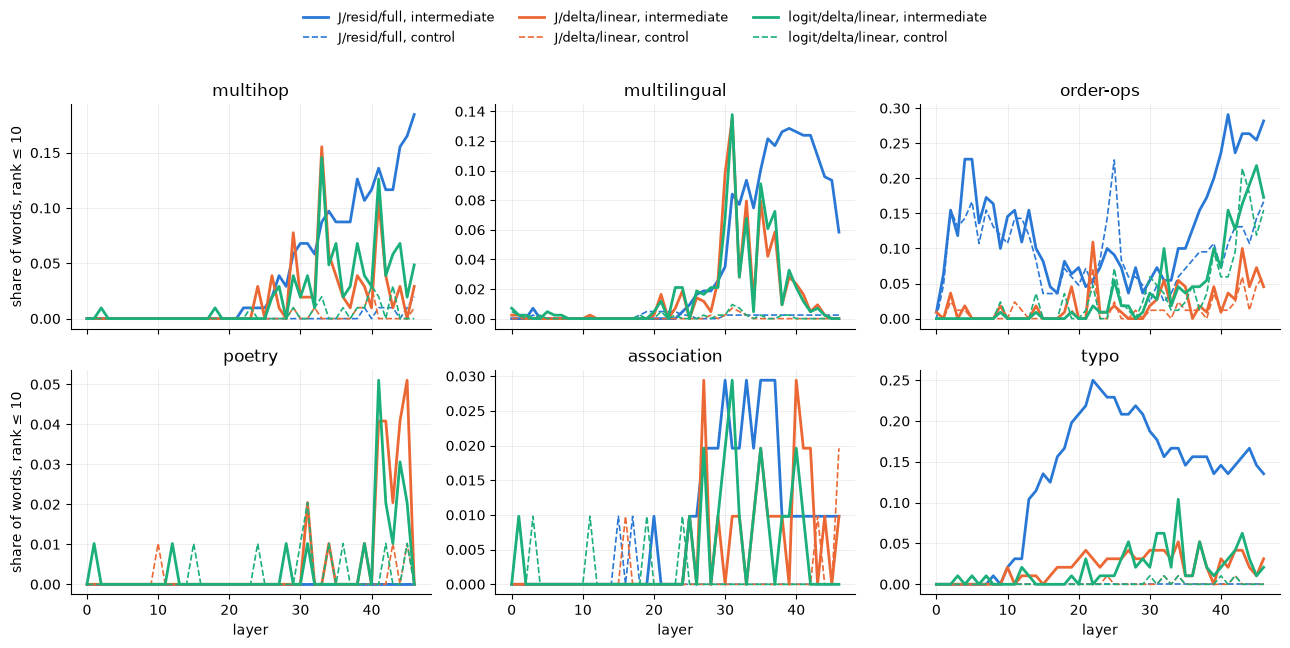

In [7]:
STYLES = {"J/resid/full": "#2a78d6", "J/delta/linear": "#eb6834", "logit/delta/linear": "#1baf7a"}
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5), sharex=True)
for ax, dataset in zip(axes.flat, DATASETS, strict=True):
    for variant, color in STYLES.items():
        for kind, style in (("intermediate", "-"), ("control", "--")):
            sel = ((words.dataset == dataset) & (words.kind == kind)).values
            hit = (ranks[variant][sel, :-1] <= K).mean(0)
            ax.plot(range(N_INNER), hit, color=color, ls=style, lw=2 if kind == "intermediate" else 1.2,
                    label=f"{variant}, {kind}")
    ax.set_title(dataset)
    ax.grid(alpha=0.25, lw=0.6)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes[-1]:
    ax.set_xlabel("layer")
for ax in axes[:, 0]:
    ax.set_ylabel(f"share of words, rank ≤ {K}")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, fontsize=9)
fig.tight_layout(rect=(0, 0, 1, 0.9))
plt.show()

## 4. Cross-validated layer choice

For each variant and dataset the items are split into random halves. On half A the layer — or
a band of 5 consecutive layers, scored by the band's best rank — with the highest intermediate
pass@10 is chosen; on half B intermediates, controls, and the margin are scored at that band.
Halves swap; the estimate averages both directions over 200 splits. CIs: nested bootstrap
(1000 item resamples × 20 splits; copies of an item stay in one half), shared across variants,
so contrasts are paired.

In [8]:
def band_hits(variant, dataset, kind, width):
    """[n_items, n_bands]: per-item hit share with band-best rank <= K."""
    return np.stack([per_item(variant, dataset, kind, layers=list(range(start, start + width)))
                     for start in range(N_INNER - width + 1)], axis=1)


def cross_validate(inter, ctrl, counts, masks, jitter):
    """Mean over splits and both directions of (intermediate, control, margin) and the chosen bands."""
    has_i, has_c = ~np.isnan(inter[:, 0]), ~np.isnan(ctrl[:, 0])
    hi, hc = np.nan_to_num(inter), np.nan_to_num(ctrl)
    score_i, score_c, chosen_all = [], [], []
    for half in (masks, 1 - masks):
        other = 1 - half
        w_select = half * counts * has_i
        chosen = np.argmax((w_select @ hi) / w_select.sum(1, keepdims=True) + jitter, axis=1)
        w_i, w_c = other * counts * has_i, other * counts * has_c
        rows_ = np.arange(len(chosen))
        score_i.append((w_i @ hi)[rows_, chosen] / w_i.sum(1))
        score_c.append((w_c @ hc)[rows_, chosen] / w_c.sum(1))
        chosen_all.append(chosen)
    score_i, score_c = np.concatenate(score_i), np.concatenate(score_c)
    return score_i.mean(), score_c.mean(), (score_i - score_c).mean(), np.concatenate(chosen_all)


def half_masks(present, n, n_splits):
    masks = np.zeros((n_splits, n))
    for split in range(n_splits):
        masks[split, rng.permutation(present)[: len(present) // 2]] = 1
    return masks


cv_rows, boot_rows = [], []
for width in CV_WIDTHS:
    n_bands = N_INNER - width + 1
    for dataset in tqdm(DATASETS, desc=f"width {width}"):
        hits = {v: (band_hits(v, dataset, "intermediate", width), band_hits(v, dataset, "control", width))
                for v in VARIANTS}
        n = next(iter(hits.values()))[0].shape[0]
        masks = half_masks(np.arange(n), n, CV_SPLITS)
        jitter = rng.uniform(0, 1e-9, size=(CV_SPLITS, n_bands))
        for v in VARIANTS:
            inter, _ = hits[v]
            score_i, score_c, margin, chosen = cross_validate(*hits[v], np.ones(n), masks, jitter)
            in_sample = np.nanmean(inter, axis=0)
            cv_rows.append({"width": width, "dataset": dataset, "variant": v, "intermediate": score_i,
                            "control": score_c, "margin": margin, "chosen median": np.median(chosen),
                            "chosen 10-90%": f"{np.percentile(chosen, 10):.0f}-{np.percentile(chosen, 90):.0f}",
                            "in-sample best": int(np.argmax(in_sample)),
                            "in-sample best intermediate": in_sample.max()})
        for b in range(CV_BOOT):
            counts = np.bincount(rng.integers(0, n, n), minlength=n).astype(float)
            masks = half_masks(np.flatnonzero(counts), n, CV_BOOT_SPLITS)
            jitter = rng.uniform(0, 1e-9, size=(CV_BOOT_SPLITS, n_bands))
            for v in VARIANTS:
                score_i, score_c, margin, _ = cross_validate(*hits[v], counts, masks, jitter)
                boot_rows.append({"width": width, "dataset": dataset, "variant": v, "b": b,
                                  "intermediate": score_i, "control": score_c, "margin": margin})
cv = pd.DataFrame(cv_rows)
cv_boot = pd.DataFrame(boot_rows)
cv.to_csv(OUT_DIR / "cv_layers.csv", index=False)

width 1:   0%|          | 0/6 [00:00<?, ?it/s]

width 5:   0%|          | 0/6 [00:00<?, ?it/s]

### CV pass@10 margin (intermediate − control) on held-out items, 95% CI

In [9]:
def cv_table(width, quantity):
    sub = cv[cv.width == width].set_index(["dataset", "variant"])
    boot = cv_boot[cv_boot.width == width].groupby(["dataset", "variant"])[quantity]
    lo, hi = boot.quantile(0.025), boot.quantile(0.975)
    text = pd.Series([f"{sub.loc[key, quantity]:.3f} [{lo[key]:.3f}, {hi[key]:.3f}]" for key in sub.index],
                     index=sub.index)
    return text.unstack("dataset")[DATASETS]


for width in CV_WIDTHS:
    for quantity in ("margin", "intermediate", "control"):
        print(f"width {width}: CV pass@{K}, {quantity}")
        display(cv_table(width, quantity))

width 1: CV pass@10, margin


dataset,multihop,multilingual,order-ops,poetry,association,typo
variant,,,,,,
J/delta/full,"0.150 [0.047, 0.226]","0.133 [0.101, 0.158]","-0.008 [-0.054, 0.062]","0.025 [-0.003, 0.067]","0.011 [0.000, 0.039]","0.016 [0.002, 0.057]"
J/delta/linear,"0.155 [0.058, 0.228]","0.129 [0.097, 0.154]","0.017 [-0.030, 0.069]","0.022 [-0.003, 0.059]","0.009 [-0.008, 0.031]","0.010 [0.000, 0.043]"
J/resid/full,"0.163 [0.088, 0.247]","0.120 [0.095, 0.149]","0.140 [0.034, 0.229]","0.000 [0.000, 0.000]","0.014 [0.000, 0.038]","0.216 [0.112, 0.285]"
J/resid/linear,"0.140 [0.070, 0.217]","0.123 [0.096, 0.149]","0.135 [0.032, 0.226]","0.000 [0.000, 0.000]","0.015 [0.000, 0.037]","0.193 [0.106, 0.265]"
logit/delta/full,"0.137 [0.045, 0.219]","0.128 [0.099, 0.154]","0.056 [-0.034, 0.171]","0.011 [-0.013, 0.039]","0.007 [-0.001, 0.030]","0.058 [0.013, 0.115]"
logit/delta/linear,"0.113 [0.030, 0.189]","0.128 [0.099, 0.154]","0.026 [-0.050, 0.160]","0.030 [-0.009, 0.064]","0.006 [-0.004, 0.027]","0.063 [0.010, 0.121]"
logit/resid/full,"0.180 [0.090, 0.272]","0.136 [0.108, 0.162]","0.047 [-0.049, 0.156]","-0.005 [-0.018, 0.002]","0.016 [0.000, 0.042]","0.135 [0.066, 0.203]"
logit/resid/linear,"0.186 [0.087, 0.273]","0.135 [0.108, 0.160]","0.064 [-0.030, 0.169]","-0.003 [-0.012, 0.003]","0.016 [0.000, 0.044]","0.140 [0.070, 0.216]"


width 1: CV pass@10, intermediate


dataset,multihop,multilingual,order-ops,poetry,association,typo
variant,,,,,,
J/delta/full,"0.153 [0.057, 0.226]","0.140 [0.108, 0.163]","0.091 [0.048, 0.150]","0.031 [0.008, 0.071]","0.011 [0.000, 0.039]","0.018 [0.006, 0.059]"
J/delta/linear,"0.155 [0.061, 0.229]","0.136 [0.104, 0.159]","0.076 [0.031, 0.131]","0.027 [0.006, 0.062]","0.010 [0.000, 0.031]","0.013 [0.004, 0.046]"
J/resid/full,"0.180 [0.098, 0.257]","0.122 [0.098, 0.150]","0.256 [0.184, 0.331]","0.000 [0.000, 0.000]","0.014 [0.000, 0.038]","0.216 [0.112, 0.285]"
J/resid/linear,"0.157 [0.080, 0.237]","0.125 [0.098, 0.151]","0.260 [0.158, 0.323]","0.000 [0.000, 0.000]","0.015 [0.000, 0.037]","0.193 [0.106, 0.265]"
logit/delta/full,"0.159 [0.068, 0.239]","0.138 [0.110, 0.161]","0.188 [0.120, 0.273]","0.012 [0.000, 0.040]","0.007 [0.000, 0.030]","0.065 [0.017, 0.123]"
logit/delta/linear,"0.135 [0.055, 0.207]","0.138 [0.110, 0.161]","0.170 [0.110, 0.272]","0.031 [0.000, 0.064]","0.006 [0.000, 0.027]","0.072 [0.016, 0.129]"
logit/resid/full,"0.202 [0.113, 0.287]","0.138 [0.112, 0.165]","0.317 [0.233, 0.383]","0.000 [0.000, 0.002]","0.016 [0.000, 0.042]","0.137 [0.067, 0.204]"
logit/resid/linear,"0.207 [0.111, 0.287]","0.137 [0.112, 0.163]","0.310 [0.247, 0.379]","0.001 [0.000, 0.004]","0.016 [0.000, 0.044]","0.147 [0.074, 0.218]"


width 1: CV pass@10, control


...

dataset,multihop,multilingual,order-ops,poetry,association,typo
variant,,,,,,
J/delta/full,"0.193 [0.107, 0.293]","0.171 [0.135, 0.195]","0.061 [-0.028, 0.178]","0.106 [0.020, 0.174]","0.030 [0.008, 0.069]","0.105 [0.061, 0.181]"
J/delta/linear,"0.174 [0.101, 0.283]","0.171 [0.135, 0.195]","0.103 [0.002, 0.201]","0.094 [0.016, 0.155]","0.027 [-0.005, 0.064]","0.096 [0.055, 0.171]"
J/resid/full,"0.204 [0.114, 0.293]","0.139 [0.107, 0.171]","0.154 [0.034, 0.252]","0.000 [0.000, 0.000]","0.021 [-0.001, 0.047]","0.230 [0.140, 0.327]"
J/resid/linear,"0.213 [0.120, 0.291]","0.141 [0.109, 0.173]","0.149 [0.043, 0.249]","0.000 [0.000, 0.000]","0.019 [-0.001, 0.044]","0.230 [0.132, 0.312]"
logit/delta/full,"0.188 [0.100, 0.284]","0.149 [0.122, 0.177]","0.131 [0.001, 0.253]","0.039 [-0.010, 0.081]","0.031 [0.004, 0.067]","0.171 [0.082, 0.252]"
logit/delta/linear,"0.179 [0.084, 0.279]","0.151 [0.121, 0.179]","0.087 [-0.040, 0.200]","0.068 [-0.008, 0.120]","0.035 [0.005, 0.073]","0.137 [0.068, 0.212]"
logit/resid/full,"0.220 [0.125, 0.314]","0.143 [0.114, 0.170]","0.053 [-0.049, 0.163]","-0.006 [-0.019, 0.005]","0.024 [0.001, 0.052]","0.171 [0.096, 0.243]"
logit/resid/linear,"0.209 [0.115, 0.301]","0.142 [0.113, 0.171]","0.035 [-0.042, 0.148]","-0.003 [-0.018, 0.005]","0.026 [0.001, 0.054]","0.189 [0.109, 0.267]"


width 5: CV pass@10, intermediate


dataset,multihop,multilingual,order-ops,poetry,association,typo
variant,,,,,,
J/delta/full,"0.214 [0.138, 0.305]","0.182 [0.148, 0.205]","0.285 [0.171, 0.381]","0.126 [0.055, 0.192]","0.033 [0.010, 0.073]","0.110 [0.071, 0.185]"
J/delta/linear,"0.196 [0.134, 0.292]","0.181 [0.144, 0.202]","0.219 [0.124, 0.297]","0.104 [0.037, 0.164]","0.034 [0.008, 0.070]","0.105 [0.066, 0.181]"
J/resid/full,"0.225 [0.137, 0.311]","0.141 [0.109, 0.173]","0.303 [0.223, 0.377]","0.000 [0.000, 0.000]","0.021 [0.001, 0.047]","0.230 [0.140, 0.327]"
J/resid/linear,"0.234 [0.141, 0.313]","0.143 [0.111, 0.175]","0.282 [0.201, 0.352]","0.000 [0.000, 0.000]","0.019 [0.000, 0.044]","0.230 [0.132, 0.312]"
logit/delta/full,"0.241 [0.163, 0.328]","0.158 [0.133, 0.186]","0.547 [0.439, 0.645]","0.040 [0.003, 0.081]","0.032 [0.008, 0.068]","0.183 [0.098, 0.264]"
logit/delta/linear,"0.231 [0.144, 0.322]","0.161 [0.134, 0.187]","0.505 [0.409, 0.592]","0.084 [0.017, 0.136]","0.035 [0.008, 0.074]","0.153 [0.081, 0.229]"
logit/resid/full,"0.246 [0.153, 0.331]","0.146 [0.117, 0.174]","0.404 [0.309, 0.487]","0.001 [0.000, 0.006]","0.024 [0.001, 0.052]","0.172 [0.096, 0.243]"
logit/resid/linear,"0.236 [0.143, 0.318]","0.145 [0.116, 0.172]","0.363 [0.298, 0.444]","0.002 [0.000, 0.008]","0.026 [0.001, 0.054]","0.198 [0.117, 0.276]"


width 5: CV pass@10, control


dataset,multihop,multilingual,order-ops,poetry,association,typo
variant,,,,,,
J/delta/full,"0.021 [0.003, 0.054]","0.012 [0.002, 0.022]","0.223 [0.116, 0.284]","0.020 [0.000, 0.050]","0.003 [0.000, 0.012]","0.005 [0.000, 0.019]"
J/delta/linear,"0.022 [0.003, 0.056]","0.009 [0.002, 0.018]","0.116 [0.057, 0.168]","0.010 [0.000, 0.030]","0.006 [0.000, 0.025]","0.009 [0.000, 0.023]"
J/resid/full,"0.022 [0.000, 0.053]","0.002 [0.000, 0.007]","0.149 [0.090, 0.216]","0.000 [0.000, 0.000]","0.000 [0.000, 0.004]","0.000 [0.000, 0.000]"
J/resid/linear,"0.021 [0.000, 0.051]","0.002 [0.000, 0.007]","0.133 [0.069, 0.195]","0.000 [0.000, 0.000]","0.000 [0.000, 0.003]","0.000 [0.000, 0.000]"
logit/delta/full,"0.052 [0.017, 0.095]","0.010 [0.002, 0.018]","0.416 [0.309, 0.516]","0.002 [0.000, 0.018]","0.001 [0.000, 0.009]","0.012 [0.000, 0.032]"
logit/delta/linear,"0.053 [0.015, 0.095]","0.011 [0.002, 0.019]","0.418 [0.308, 0.533]","0.016 [0.000, 0.041]","0.000 [0.000, 0.007]","0.016 [0.000, 0.037]"
logit/resid/full,"0.027 [0.000, 0.060]","0.003 [0.000, 0.008]","0.351 [0.247, 0.435]","0.007 [0.000, 0.021]","0.000 [0.000, 0.000]","0.001 [0.000, 0.006]"
logit/resid/linear,"0.026 [0.000, 0.059]","0.003 [0.000, 0.008]","0.328 [0.226, 0.407]","0.005 [0.000, 0.019]","0.000 [0.000, 0.000]","0.010 [0.000, 0.027]"


### Chosen layers: CV median (10–90%) | in-sample best layer

In [10]:
for width in CV_WIDTHS:
    sub = cv[cv.width == width]
    text = [f"{m:.0f} ({r}) | {b}" for m, r, b in
            zip(sub["chosen median"], sub["chosen 10-90%"], sub["in-sample best"], strict=True)]
    print(f"band width {width} (band start layer)")
    display(sub.assign(text=text).pivot(index="variant", columns="dataset", values="text")[DATASETS])

band width 1 (band start layer)


dataset,multihop,multilingual,order-ops,poetry,association,typo
variant,,,,,,
J/delta/full,33 (33-41) | 33,31 (31-31) | 31,34 (22-46) | 22,44 (41-45) | 42,35 (27-41) | 27,31 (26-40) | 27
J/delta/linear,33 (33-41) | 33,31 (31-31) | 31,22 (22-45) | 22,44 (41-45) | 45,40 (27-41) | 27,34 (24-42) | 34
J/resid/full,46 (44-46) | 46,39 (38-42) | 39,41 (41-46) | 41,25 (6-42) | 0,33 (28-38) | 30,22 (22-28) | 22
J/resid/linear,46 (42-46) | 46,40 (39-41) | 40,46 (41-46) | 46,25 (6-42) | 0,35 (27-39) | 33,24 (21-29) | 22
logit/delta/full,33 (33-41) | 33,31 (31-31) | 31,45 (41-45) | 45,41 (28-43) | 41,35 (27-40) | 35,34 (31-37) | 34
logit/delta/linear,33 (33-41) | 33,31 (31-31) | 31,45 (44-45) | 45,41 (41-44) | 41,31 (27-40) | 31,34 (31-34) | 34
logit/resid/full,44 (42-44) | 44,39 (37-40) | 39,36 (34-44) | 36,24 (10-37) | 22,35 (31-41) | 31,35 (28-39) | 35
logit/resid/linear,44 (43-44) | 44,39 (37-40) | 39,35 (34-44) | 34,22 (8-30) | 8,36 (31-41) | 31,38 (33-43) | 36


band width 5 (band start layer)


dataset,multihop,multilingual,order-ops,poetry,association,typo
variant,,,,,,
J/delta/full,30 (29-37) | 29,29 (29-30) | 29,42 (39-42) | 42,41 (39-41) | 41,37 (27-40) | 37,26 (19-34) | 26
J/delta/linear,32 (29-38) | 29,29 (29-30) | 29,41 (39-42) | 41,41 (39-41) | 41,39 (27-41) | 40,30 (19-40) | 30
J/resid/full,41 (41-42) | 41,39 (38-41) | 39,41 (2-42) | 41,22 (4-38) | 0,30 (24-36) | 29,19 (18-29) | 18
J/resid/linear,42 (42-42) | 42,39 (38-41) | 39,41 (2-42) | 41,22 (4-38) | 0,32 (23-37) | 29,25 (18-30) | 25
logit/delta/full,37 (32-39) | 37,31 (27-33) | 31,42 (41-42) | 42,39 (37-41) | 39,30 (26-37) | 27,31 (30-34) | 31
logit/delta/linear,37 (32-39) | 37,29 (27-32) | 27,41 (41-42) | 41,41 (38-41) | 41,30 (27-38) | 27,31 (30-40) | 30
logit/resid/full,41 (39-42) | 40,36 (35-38) | 35,30 (30-34) | 30,22 (9-35) | 18,35 (28-38) | 34,33 (24-41) | 32
logit/resid/linear,41 (40-42) | 40,36 (32-38) | 36,32 (30-37) | 30,17 (5-28) | 4,35 (28-38) | 34,40 (32-41) | 40


### Paired CV contrasts, 95% CI

In [11]:
CV_CONTRASTS = [
    ("J/delta/linear", "J/resid/full"),
    ("logit/delta/linear", "J/resid/full"),
    ("J/delta/linear", "logit/delta/linear"),
    ("J/resid/full", "logit/resid/full"),
    ("logit/delta/linear", "logit/resid/full"),
]
rows = []
for width in CV_WIDTHS:
    for dataset in DATASETS:
        boot = cv_boot[(cv_boot.width == width) & (cv_boot.dataset == dataset)].set_index(["variant", "b"])
        point = cv[(cv.width == width) & (cv.dataset == dataset)].set_index("variant")
        for a, b in CV_CONTRASTS:
            for quantity in ("intermediate", "margin"):
                diff = boot.loc[a, quantity].values - boot.loc[b, quantity].values
                rows.append({"width": width, "contrast": f"{a} − {b}", "quantity": quantity, "dataset": dataset,
                             "text": ci_text(point.loc[a, quantity] - point.loc[b, quantity], diff)})
cv_contrasts = pd.DataFrame(rows)
cv_contrasts.pivot(index=["width", "contrast", "quantity"], columns="dataset", values="text")[DATASETS]

dataset                                                                  multihop             multilingual                order-ops                   poetry              association                     typo
width contrast                              quantity                                                                                                                                                          
1     J/delta/linear − J/resid/full         intermediate  -0.025 [-0.133, +0.063]  +0.013 [-0.019, +0.034]  -0.180 [-0.268, -0.092]  +0.027 [+0.006, +0.062]  -0.004 [-0.024, +0.019]  -0.203 [-0.270, -0.092]
                                            margin        -0.008 [-0.112, +0.075]  +0.009 [-0.023, +0.032]  -0.123 [-0.220, -0.000]  +0.022 [-0.003, +0.059]  -0.005 [-0.026, +0.018]  -0.206 [-0.272, -0.092]
      J/delta/linear − logit/delta/linear   intermediate  +0.020 [-0.035, +0.065]  -0.002 [-0.020, +0.013]  -0.094 [-0.203, -0.018]  -0.004 [-0.028, +0.043]  +0.004 [-0.016, +0.024]  -0.058 [-0.110, +0.003]
                                            margin        +0.042 [-0.017, +0.088]  +0.000 [-0.017, +0.015]  -0.009 [-0.137, +0.079]  -0.007 [-0.031, +0.042]  +0.003 [-0.020, +0.024]  -0.053 [-0.105, +0.006]
      J/resid/full − logit/resid/full       intermediate  -0.021 [-0.066, +0.016]  -0.016 [-0.030, +0.001]  -0.061 [-0.139, +0.024]  -0.000 [-0.002, +0.000]  -0.002 [-0.023, +0.017]  +0.080 [-0.023, +0.162]
                                            margin        -0.017 [-0.061, +0.030]  -0.016 [-0.030, +0.001]  +0.093 [-0.024, +0.195]  +0.005 [-0.002, +0.018]  -0.002 [-0.023, +0.017]  +0.081 [-0.022, +0.163]
      logit/delta/linear − J/resid/full     intermediate  -0.045 [-0.145, +0.042]  +0.016 [-0.015, +0.038]  -0.086 [-0.165, +0.026]  +0.031 [+0.000, +0.064]  -0.008 [-0.026, +0.010]  -0.144 [-0.242, -0.045]
                                            margin        -0.050 [-0.144, +0.033]  +0.009 [-0.022, +0.033]  -0.114 [-0.220, +0.037]  +0.030 [-0.009, +0.064]  -0.008 [-0.027, +0.010]  -0.153 [-0.248, -0.050]
      logit/delta/linear − logit/resid/full intermediate  -0.067 [-0.164, +0.021]  -0.001 [-0.029, +0.025]  -0.147 [-0.225, -0.020]  +0.030 [-0.000, +0.064]  -0.010 [-0.034, +0.012]  -0.065 [-0.146, -0.003]
                                            margin        -0.067 [-0.167, +0.021]  -0.008 [-0.036, +0.018]  -0.021 [-0.150, +0.122]  +0.035 [-0.008, +0.069]  -0.010 [-0.037, +0.012]  -0.072 [-0.150, -0.010]
5     J/delta/linear − J/resid/full         intermediate  -0.029 [-0.103, +0.076]  +0.040 [-0.002, +0.067]  -0.084 [-0.192, +0.004]  +0.104 [+0.037, +0.164]  +0.012 [-0.010, +0.055]  -0.126 [-0.220, -0.024]
                                            margin        -0.029 [-0.105, +0.084]  +0.033 [-0.010, +0.063]  -0.051 [-0.164, +0.064]  +0.094 [+0.016, +0.155]  +0.006 [-0.019, +0.051]  -0.135 [-0.225, -0.033]
      J/delta/linear − logit/delta/linear   intermediate  -0.035 [-0.107, +0.066]  +0.019 [-0.007, +0.036]  -0.286 [-0.400, -0.208]  +0.020 [-0.009, +0.059]  -0.001 [-0.035, +0.031]  -0.048 [-0.109, +0.038]
                                            margin        -0.004 [-0.087, +0.108]  +0.021 [-0.006, +0.036]  +0.016 [-0.125, +0.146]  +0.026 [-0.011, +0.068]  -0.008 [-0.043, +0.030]  -0.042 [-0.103, +0.045]
      J/resid/full − logit/resid/full       intermediate  -0.021 [-0.069, +0.027]  -0.005 [-0.020, +0.013]  -0.101 [-0.218, +0.009]  -0.001 [-0.006, +0.000]  -0.002 [-0.026, +0.015]  +0.058 [-0.034, +0.153]
                                            margin        -0.016 [-0.075, +0.037]  -0.004 [-0.020, +0.013]  +0.101 [-0.053, +0.206]  +0.006 [-0.005, +0.019]  -0.003 [-0.026, +0.015]  +0.059 [-0.034, +0.153]
      logit/delta/linear − J/resid/full     intermediate  +0.006 [-0.091, +0.107]  +0.020 [-0.013, +0.050]  +0.202 [+0.099, +0.305]  +0.084 [+0.017, +0.136]  +0.014 [-0.007, +0.048]  -0.077 [-0.187, +0.019]
                                            margin        -0.025 [-

## 5. Conclusions

* **Min over all layers favours deltas for the wrong reason.** Delta hits are sparse and land on
  different layers for different words (§3); the minimum over 47 layers collects them, and
  controls rise too. On any single layer the stream is read far better (e.g. typo: ~25% of
  words at rank ≤ 10 on the stream vs ≤ 10% on deltas).
* **With a cross-validated layer** deltas are not better than the stream on any dataset, and
  much worse on typo (margin 0.010 vs 0.216) and borderline worse on order-ops. With a band of 5 layers they are significantly
  better only on **poetry** (the stream never surfaces the rhyme; blocks 41–45 write it),
  borderline on multilingual (block 31 is chosen in every single-layer split), and
  significantly worse on typo, whose answer accumulates in the stream over many layers rather
  than being written by one block.
* **J transport adds nothing over DLA on deltas**: no margin contrast between `J/delta/linear`
  and `logit/delta/linear` is significant. With a cross-validated layer, J-lens on the stream is
  also not significantly better than the logit lens — its order-ops advantage (+0.127 with the
  min over layers) shrinks to a non-significant +0.093 [−0.024, 0.195].

Open directions: per-role analysis of multilingual around block 31, attention vs MLP within
blocks, and the path sum `Σ_{j≤l} J_j Δ_j`, which transports each block's write by its own
Jacobian.